In [1]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import accuracy_score, log_loss
import pymc as pm
import arviz as az
import joblib

DATA_PATH = '/content/latest.csv'
df = pd.read_csv(DATA_PATH)

In [2]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['Day']   = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year']  = df['Date'].dt.year
df['Hour']  = df['Time'].apply(lambda x: int(str(x).split(':')[0]))
df['Min']   = df['Time'].apply(lambda x: int(str(x).split(':')[1]))

keep_cols = ['Date','Day','Month','Year','Hour','Min','HomeTeam','AwayTeam',
             'FTHG','FTAG','HTHG','HTAG','HS','AS','HST','AST','HF','AF',
             'HC','AC','HY','AY','HR','AR','FTR','Referee','B365H','B365D','B365A']
df = df[keep_cols].copy()
df = df.sort_values(by=['Date','Hour','Min']).reset_index(drop=True)

In [3]:
FUTURE_FIXTURES = pd.DataFrame({
    'HomeTeam': ['Brentford','Man City','Liverpool','Newcastle','Chelsea','Aston Villa'],
    'AwayTeam': ['Man United','Arsenal','Brighton','West Ham','Burnley','Wolves'],
    'Date':     pd.to_datetime(['2024-03-30','2024-03-31','2024-03-31','2024-03-30','2024-03-30','2024-03-30']),
    'Hour':     [20, 16, 14, 12, 15, 17],   # fixed: 25 was invalid, changed to 17
    'Min':      [0, 30, 0, 30, 0, 0],
})
FUTURE_FIXTURES['Day']   = FUTURE_FIXTURES['Date'].dt.day
FUTURE_FIXTURES['Month'] = FUTURE_FIXTURES['Date'].dt.month
FUTURE_FIXTURES['Year']  = FUTURE_FIXTURES['Date'].dt.year

df_all = pd.concat([df, FUTURE_FIXTURES], ignore_index=True)
df_all = df_all.sort_values(by=['Date','Hour','Min']).reset_index(drop=True)
df_all['match_id'] = df_all.index

In [4]:
def compute_elo(df_all, k=20, base=1500, home_adv=60):
    elo = {}
    home_elo_pre, away_elo_pre = [], []
    for _, row in df_all.iterrows():
        h, a = row['HomeTeam'], row['AwayTeam']
        rh, ra = elo.get(h, base), elo.get(a, base)
        home_elo_pre.append(rh)
        away_elo_pre.append(ra)
        if pd.isna(row['FTR']):
            continue  # future fixture -> don't update ratings yet
        exp_h = 1 / (1 + 10 ** (-(rh + home_adv - ra) / 400))
        score_h = 1.0 if row['FTR'] == 'H' else (0.5 if row['FTR'] == 'D' else 0.0)
        elo[h] = rh + k * (score_h - exp_h)
        elo[a] = ra + k * ((1 - score_h) - (1 - exp_h))
    df_all['home_elo_pre'] = home_elo_pre
    df_all['away_elo_pre'] = away_elo_pre
    return df_all

df_all = compute_elo(df_all)

In [5]:
home_view = df_all.rename(columns={
    'HomeTeam':'team_playing', 'AwayTeam':'opponent',
    'FTHG':'tp_goals','FTAG':'op_goals','HTHG':'tp_ht_goals','HTAG':'op_ht_goals',
    'HS':'tp_shots','AS':'op_shots','HST':'tp_shots_on_target','AST':'op_shots_on_target',
    'HF':'tp_fouls','AF':'op_fouls','HC':'tp_corners','AC':'op_corners',
    'HY':'tp_yellow','AY':'op_yellow','HR':'tp_red','AR':'op_red',
    'home_elo_pre':'tp_elo_pre','away_elo_pre':'op_elo_pre',
    'B365H':'tp_odds_win','B365A':'tp_odds_loss',
})
home_view['is_home'] = 1

away_view = df_all.rename(columns={
    'AwayTeam':'team_playing', 'HomeTeam':'opponent',
    'FTAG':'tp_goals','FTHG':'op_goals','HTAG':'tp_ht_goals','HTHG':'op_ht_goals',
    'AS':'tp_shots','HS':'op_shots','AST':'tp_shots_on_target','HST':'op_shots_on_target',
    'AF':'tp_fouls','HF':'op_fouls','AC':'tp_corners','HC':'op_corners',
    'AY':'tp_yellow','HY':'op_yellow','AR':'tp_red','HR':'op_red',
    'away_elo_pre':'tp_elo_pre','home_elo_pre':'op_elo_pre',
    'B365A':'tp_odds_win','B365H':'tp_odds_loss',
})
away_view['is_home'] = 0

common_cols = ['match_id','Date','Day','Month','Year','Hour','team_playing','opponent','is_home',
               'tp_goals','op_goals','tp_ht_goals','op_ht_goals','tp_shots','op_shots',
               'tp_shots_on_target','op_shots_on_target','tp_fouls','op_fouls','tp_corners',
               'op_corners','tp_yellow','op_yellow','tp_red','op_red','tp_elo_pre','op_elo_pre',
               'tp_odds_win','tp_odds_loss','B365D','FTR','Referee']

data = pd.concat([home_view[common_cols], away_view[common_cols]], ignore_index=True)
data = data.sort_values(by=['Date','Hour','match_id']).reset_index(drop=True)

def get_result(row):
    if pd.isna(row['FTR']):
        return np.nan
    if row['FTR'] == 'D':
        return 1
    won = (row['is_home'] == 1 and row['FTR'] == 'H') or (row['is_home'] == 0 and row['FTR'] == 'A')
    return 2 if won else 0

data['target'] = data.apply(get_result, axis=1)          # 0=Loss, 1=Draw, 2=Win
data['target_binary'] = (data['target'] == 2).astype('Int64')

In [6]:
data['odds_win_raw']  = 1 / data['tp_odds_win']
data['odds_draw_raw'] = 1 / data['B365D']
data['odds_loss_raw'] = 1 / data['tp_odds_loss']
overround = data['odds_win_raw'] + data['odds_draw_raw'] + data['odds_loss_raw']
data['implied_prob_win']  = data['odds_win_raw'] / overround
data['implied_prob_draw'] = data['odds_draw_raw'] / overround
data['implied_prob_loss'] = data['odds_loss_raw'] / overround

In [7]:
data = data.sort_values(by=['team_playing', 'Date', 'Hour']).reset_index(drop=True)

roll_source_cols = ['tp_goals','op_goals','tp_shots','tp_shots_on_target',
                     'op_shots','tp_corners','op_fouls','target_binary']
WINDOW = 5
grouped = data.groupby('team_playing')[roll_source_cols]

# closed='left' -> current match EXCLUDED, only strictly-past matches used
rolling_mean = grouped.transform(lambda s: s.rolling(window=WINDOW, closed='left').mean())
rolling_mean.columns = [f'{c}_form5' for c in roll_source_cols]

# EWM version -> recent matches weighted more heavily
ewm_mean = grouped.transform(lambda s: s.shift(1).ewm(span=WINDOW, min_periods=1).mean())
ewm_mean.columns = [f'{c}_ewm' for c in roll_source_cols]

data = pd.concat([data, rolling_mean, ewm_mean], axis=1)

# early-season NaNs -> fill with that team's own expanding (so-far) mean, NOT bfill (bfill leaks future backward)
expanding_fallback = grouped.transform(lambda s: s.shift(1).expanding().mean())
expanding_fallback.columns = [f'{c}_expand' for c in roll_source_cols]
data = pd.concat([data, expanding_fallback], axis=1)

form_cols = list(rolling_mean.columns) + list(ewm_mean.columns)
for c in roll_source_cols:
    data[f'{c}_form5'] = data[f'{c}_form5'].fillna(data[f'{c}_expand'])
    data[f'{c}_ewm']   = data[f'{c}_ewm'].fillna(data[f'{c}_expand'])
data = data.drop(columns=list(expanding_fallback.columns))
data[form_cols] = data[form_cols].fillna(data[form_cols].mean())  # very first ever matches -> league avg

data = data.sort_values(by=['Date','Hour','match_id']).reset_index(drop=True)

In [8]:
hist   = data[data['target'].notna()].copy()
future = data[data['target'].isna()].copy()

candidate_features = [
    'is_home', 'tp_elo_pre', 'op_elo_pre',
    'tp_goals_form5', 'op_goals_form5', 'tp_shots_form5', 'tp_shots_on_target_form5',
    'op_shots_form5', 'tp_corners_form5', 'op_fouls_form5', 'target_binary_form5',
    'tp_goals_ewm', 'target_binary_ewm', 'implied_prob_win', 'implied_prob_draw',
]

X_vif = add_constant(hist[candidate_features])
vif_df = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
selected_features = vif_df[(vif_df['VIF'] < 5) & (vif_df['feature'] != 'const')]['feature'].tolist()
print("Selected features (VIF < 5):", selected_features)

# chronological split -> last ~20% of dates = test set (NO random shuffling for time-series data)
cutoff_date = hist['Date'].quantile(0.8, interpolation='nearest')
train_df = hist[hist['Date'] <= cutoff_date].reset_index(drop=True)
test_df  = hist[hist['Date'] >  cutoff_date].reset_index(drop=True)
print(f"Cutoff date: {cutoff_date.date()}  ->  train={len(train_df)}  test={len(test_df)}")

X_train_raw, X_test_raw = train_df[selected_features], test_df[selected_features]
X_future_raw = future[selected_features].fillna(train_df[selected_features].median())
y_train, y_test = train_df['target'].astype(int).values, test_df['target'].astype(int).values

scaler = StandardScaler()                       # fit ONLY on train -> no leakage
X_train  = scaler.fit_transform(X_train_raw)
X_test   = scaler.transform(X_test_raw)
X_future = scaler.transform(X_future_raw)

Selected features (VIF < 5): ['is_home', 'tp_elo_pre', 'op_elo_pre', 'op_goals_form5', 'tp_shots_form5', 'tp_shots_on_target_form5', 'op_shots_form5', 'tp_corners_form5', 'op_fouls_form5', 'implied_prob_win', 'implied_prob_draw']
Cutoff date: 2024-02-04  ->  train=454  test=112


In [9]:
majority_class = pd.Series(y_train).mode()[0]
baseline_acc = (y_test == majority_class).mean()

book_probs_test = test_df[['implied_prob_loss','implied_prob_draw','implied_prob_win']].values
book_logloss = log_loss(y_test, book_probs_test, labels=[0,1,2])
book_acc = (book_probs_test.argmax(axis=1) == y_test).mean()

print(f"Baseline A (majority class): accuracy = {baseline_acc:.3f}")
print(f"Baseline B (bookmaker odds): accuracy = {book_acc:.3f}, log-loss = {book_logloss:.3f}")

Baseline A (majority class): accuracy = 0.402
Baseline B (bookmaker odds): accuracy = 0.643, log-loss = 0.862


In [10]:
tscv = TimeSeriesSplit(n_splits=5)
grid = GridSearchCV(LogisticRegression(max_iter=2000),
                     {'C': [0.01, 0.03, 0.1, 0.3, 1, 3, 10]}, cv=tscv, scoring='neg_log_loss')
grid.fit(X_train, y_train)
logit_model = grid.best_estimator_
print("Best C:", grid.best_params_)

p_pred_logit = logit_model.predict_proba(X_test)
y_pred_logit = p_pred_logit.argmax(axis=1)
acc_logit = accuracy_score(y_test, y_pred_logit)
ll_logit  = log_loss(y_test, p_pred_logit, labels=[0,1,2])
y_test_onehot = np.eye(3)[y_test]
brier_logit = np.mean(np.sum((p_pred_logit - y_test_onehot) ** 2, axis=1))
print(f"Multinomial LR -> accuracy={acc_logit:.3f}  log_loss={ll_logit:.3f}  brier={brier_logit:.3f}")

Best C: {'C': 0.03}
Multinomial LR -> accuracy=0.616  log_loss=0.872  brier=0.509


In [11]:
n_features, n_classes = X_train.shape[1], 3   # 0=Loss (reference), 1=Draw, 2=Win

with pm.Model() as bayes_model:
    X_data = pm.Data('X_data', X_train)
    beta  = pm.Normal('beta',  mu=0, sigma=1, shape=(n_classes - 1, n_features))  # standardized features!
    alpha = pm.Normal('alpha', mu=0, sigma=1, shape=(n_classes - 1,))

    logits_rest = alpha + pm.math.dot(X_data, beta.T)
    logits_ref  = pm.math.zeros_like(logits_rest[:, :1])            # Loss fixed as reference class
    logits = pm.math.concatenate([logits_ref, logits_rest], axis=1)

    p = pm.Deterministic('p', pm.math.softmax(logits, axis=1))
    y_obs = pm.Categorical('y_obs', p=p, observed=y_train)

    trace = pm.sample(1000, tune=1000, cores=3, target_accept=0.9, random_seed=42)

print(az.summary(trace, var_names=['beta', 'alpha']).describe())
print("Max r_hat:", az.summary(trace, var_names=['beta','alpha'])['r_hat'].max())

Output()

            mean         sd     hdi_3%    hdi_97%  mcse_mean    mcse_sd  \
count  24.000000  24.000000  24.000000  24.000000  24.000000  24.000000   
mean    0.069083   0.178542  -0.261667   0.406667   0.003458   0.002875   
std     0.372755   0.036372   0.338846   0.412539   0.000779   0.000741   
min    -0.497000   0.133000  -0.742000  -0.218000   0.002000   0.002000   
25%    -0.094000   0.151000  -0.471500   0.243000   0.003000   0.002000   
50%     0.009000   0.164500  -0.279500   0.340500   0.003000   0.003000   
75%     0.168500   0.208000  -0.180250   0.490000   0.004000   0.003000   
max     1.375000   0.252000   0.941000   1.792000   0.005000   0.004000   

          ess_bulk     ess_tail  r_hat  
count    24.000000    24.000000   24.0  
mean   3051.083333  2358.541667    1.0  
std     506.520862   194.972011    0.0  
min    2185.000000  1898.000000    1.0  
25%    2793.500000  2326.000000    1.0  
50%    3018.000000  2384.000000    1.0  
75%    3437.000000  2451.000000    1.

In [12]:
with bayes_model:
    pm.set_data({'X_data': X_test})
    post_pred_test = pm.sample_posterior_predictive(trace, var_names=['p'])

p_samples_test = post_pred_test.posterior_predictive['p'].values
p_samples_test = p_samples_test.reshape(-1, p_samples_test.shape[-2], p_samples_test.shape[-1])
p_mean_test = p_samples_test.mean(axis=0)                 # avg over ALL posterior samples
p_spread_test = p_samples_test.max(axis=0) - p_samples_test.min(axis=0)   # uncertainty

y_pred_bayes = p_mean_test.argmax(axis=1)
acc_bayes = accuracy_score(y_test, y_pred_bayes)
ll_bayes = log_loss(y_test, p_mean_test, labels=[0,1,2])
brier_bayes = np.mean(np.sum((p_mean_test - y_test_onehot) ** 2, axis=1))
print(f"Bayesian Multinomial LR -> accuracy={acc_bayes:.3f}  log_loss={ll_bayes:.3f}  brier={brier_bayes:.3f}")

Output()

Bayesian Multinomial LR -> accuracy=0.634  log_loss=0.873  brier=0.510


In [13]:
calib_df = pd.DataFrame({'p_win': p_mean_test[:, 2], 'actual_win': (y_test == 2).astype(int)})
calib_df['bucket'] = pd.cut(calib_df['p_win'], bins=[0, 0.3, 0.5, 0.7, 1.0])
calibration = calib_df.groupby('bucket', observed=True).agg(
    predicted_avg=('p_win', 'mean'), actual_rate=('actual_win', 'mean'), n=('p_win', 'size'))
print("Calibration (predicted vs actual win-rate):")
print(calibration)

Calibration (predicted vs actual win-rate):
            predicted_avg  actual_rate   n
bucket                                    
(0.0, 0.3]       0.184652     0.135135  37
(0.3, 0.5]       0.382719     0.361111  36
(0.5, 0.7]       0.576606     0.571429  21
(0.7, 1.0]       0.798486     0.833333  18


In [14]:
with bayes_model:
    pm.set_data({'X_data': X_future})
    post_pred_future = pm.sample_posterior_predictive(trace, var_names=['p'])

p_samples_future = post_pred_future.posterior_predictive['p'].values
p_samples_future = p_samples_future.reshape(-1, p_samples_future.shape[-2], p_samples_future.shape[-1])
p_mean_future = p_samples_future.mean(axis=0)
p_lo, p_hi = np.percentile(p_samples_future, [5.5, 94.5], axis=0)

future_results = future[['team_playing', 'opponent', 'is_home']].reset_index(drop=True)
future_results['P(Loss)'] = p_mean_future[:, 0].round(3)
future_results['P(Draw)'] = p_mean_future[:, 1].round(3)
future_results['P(Win)']  = p_mean_future[:, 2].round(3)
future_results['P(Win) 89% CI'] = [f"[{a:.2f}, {b:.2f}]" for a, b in zip(p_lo[:,2], p_hi[:,2])]
print(future_results)

Output()

   team_playing     opponent  is_home  P(Loss)  P(Draw)  P(Win) P(Win) 89% CI
0     Newcastle     West Ham        1    0.421    0.255   0.324  [0.22, 0.44]
1      West Ham    Newcastle        0    0.426    0.258   0.317  [0.23, 0.41]
2       Burnley      Chelsea        0    0.353    0.198   0.449  [0.26, 0.64]
3       Chelsea      Burnley        1    0.424    0.187   0.389  [0.19, 0.61]
4   Aston Villa       Wolves        1    0.427    0.307   0.266  [0.16, 0.40]
5        Wolves  Aston Villa        0    0.260    0.328   0.411  [0.27, 0.57]
6     Brentford   Man United        1    0.319    0.218   0.464  [0.31, 0.62]
7    Man United    Brentford        0    0.481    0.241   0.278  [0.11, 0.48]
8      Brighton    Liverpool        0    0.334    0.323   0.343  [0.18, 0.53]
9     Liverpool     Brighton        1    0.352    0.275   0.374  [0.17, 0.60]
10      Arsenal     Man City        0    0.251    0.327   0.422  [0.24, 0.62]
11     Man City      Arsenal        1    0.264    0.347   0.390 

In [15]:
joblib.dump(logit_model, 'multinomial_logreg_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
joblib.dump(selected_features, 'selected_features.pkl')
joblib.dump(trace, 'bayesian_trace.pkl')
print("Models saved.")

Models saved.


In [16]:
print(f"{'Model':<30}{'Accuracy':<12}{'LogLoss':<12}{'Brier':<10}")
print(f"{'Majority-class baseline':<30}{baseline_acc:<12.3f}{'-':<12}{'-':<10}")
print(f"{'Bookmaker implied odds':<30}{book_acc:<12.3f}{book_logloss:<12.3f}{'-':<10}")
print(f"{'Multinomial Logistic Reg.':<30}{acc_logit:<12.3f}{ll_logit:<12.3f}{brier_logit:<10.3f}")
print(f"{'Bayesian Multinomial LR':<30}{acc_bayes:<12.3f}{ll_bayes:<12.3f}{brier_bayes:<10.3f}")

Model                         Accuracy    LogLoss     Brier     
Majority-class baseline       0.402       -           -         
Bookmaker implied odds        0.643       0.862       -         
Multinomial Logistic Reg.     0.616       0.872       0.509     
Bayesian Multinomial LR       0.634       0.873       0.510     


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.style.use('dark_background')
PALETTE = ['#3B82F6', '#F59E0B', '#10B981', '#EF4444']   # blue, amber, green, red

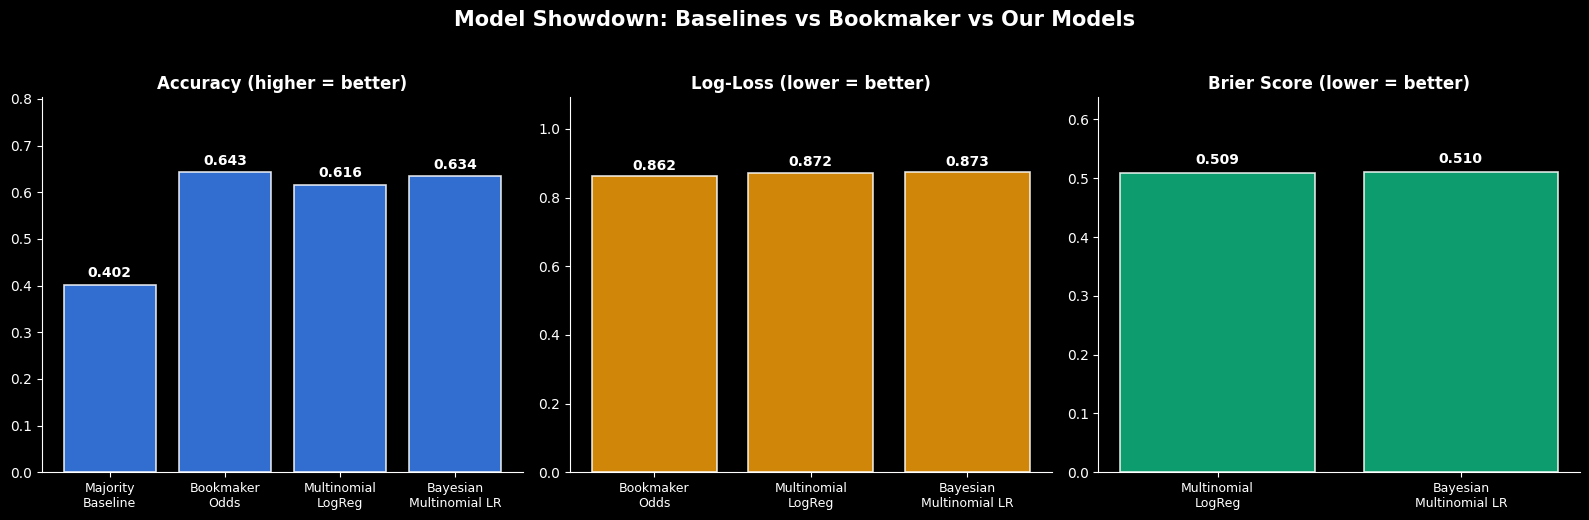

In [18]:
comparison = pd.DataFrame({
    'Model': ['Majority\nBaseline', 'Bookmaker\nOdds', 'Multinomial\nLogReg', 'Bayesian\nMultinomial LR'],
    'Accuracy': [baseline_acc, book_acc, acc_logit, acc_bayes],
    'LogLoss':  [np.nan, book_logloss, ll_logit, ll_bayes],
    'Brier':    [np.nan, np.nan, brier_logit, brier_bayes],
})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['Accuracy', 'LogLoss', 'Brier']
titles = ['Accuracy (higher = better)', 'Log-Loss (lower = better)', 'Brier Score (lower = better)']
for ax, metric, title, color in zip(axes, metrics, titles, PALETTE):
    vals = comparison[metric]
    bars = ax.bar(comparison['Model'], vals, color=color, alpha=0.85, edgecolor='white', linewidth=1.2)
    for bar, v in zip(bars, vals):
        if pd.notna(v):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{v:.3f}',
                     ha='center', va='bottom', fontsize=10, fontweight='bold', color='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim(0, max([v for v in vals if pd.notna(v)]) * 1.25)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='x', labelsize=9)
fig.suptitle('Model Showdown: Baselines vs Bookmaker vs Our Models', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('viz1_model_comparison.png', dpi=150, bbox_inches='tight', facecolor='#111111')
plt.show()

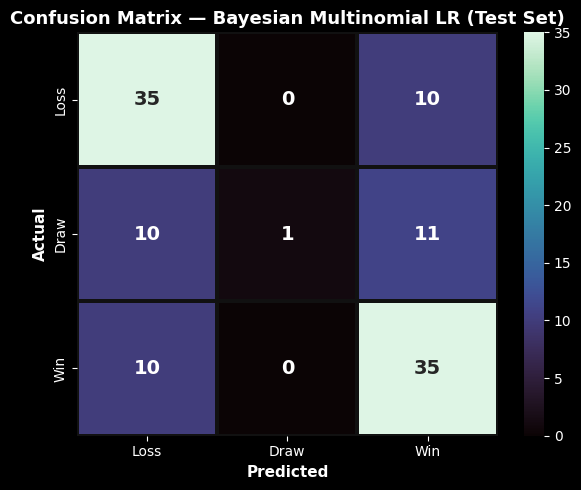

In [19]:
cm = confusion_matrix(y_test, y_pred_bayes, labels=[0, 1, 2])
labels = ['Loss', 'Draw', 'Win']

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='mako', cbar=True,
            xticklabels=labels, yticklabels=labels, linewidths=1.5, linecolor='#111111',
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
ax.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax.set_ylabel('Actual', fontsize=11, fontweight='bold')
ax.set_title('Confusion Matrix — Bayesian Multinomial LR (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz2_confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#111111')
plt.show()

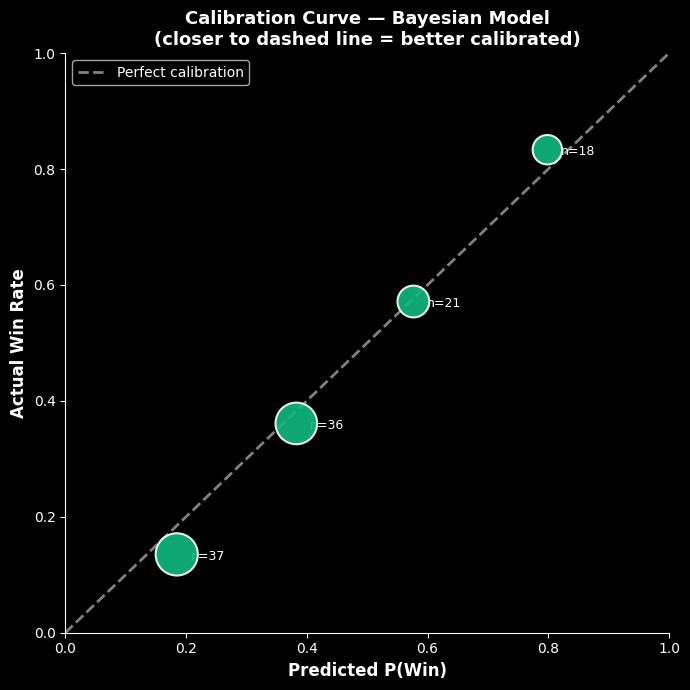

In [20]:
calib_plot_df = calib_df.copy()
calib_grouped = calib_plot_df.groupby('bucket', observed=True).agg(
    predicted=('p_win', 'mean'), actual=('actual_win', 'mean'), n=('p_win', 'size')
).reset_index()

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=2, label='Perfect calibration')
sizes = calib_grouped['n'] * 25
ax.scatter(calib_grouped['predicted'], calib_grouped['actual'], s=sizes,
           c=PALETTE[2], edgecolor='white', linewidth=1.5, zorder=5, alpha=0.9)
for _, r in calib_grouped.iterrows():
    ax.annotate(f"n={int(r['n'])}", (r['predicted'], r['actual']),
                textcoords="offset points", xytext=(10, -4), fontsize=9, color='white')
ax.set_xlabel('Predicted P(Win)', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual Win Rate', fontsize=12, fontweight='bold')
ax.set_title('Calibration Curve — Bayesian Model\n(closer to dashed line = better calibrated)',
              fontsize=13, fontweight='bold')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(loc='upper left', fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz3_calibration.png', dpi=150, bbox_inches='tight', facecolor='#111111')
plt.show()

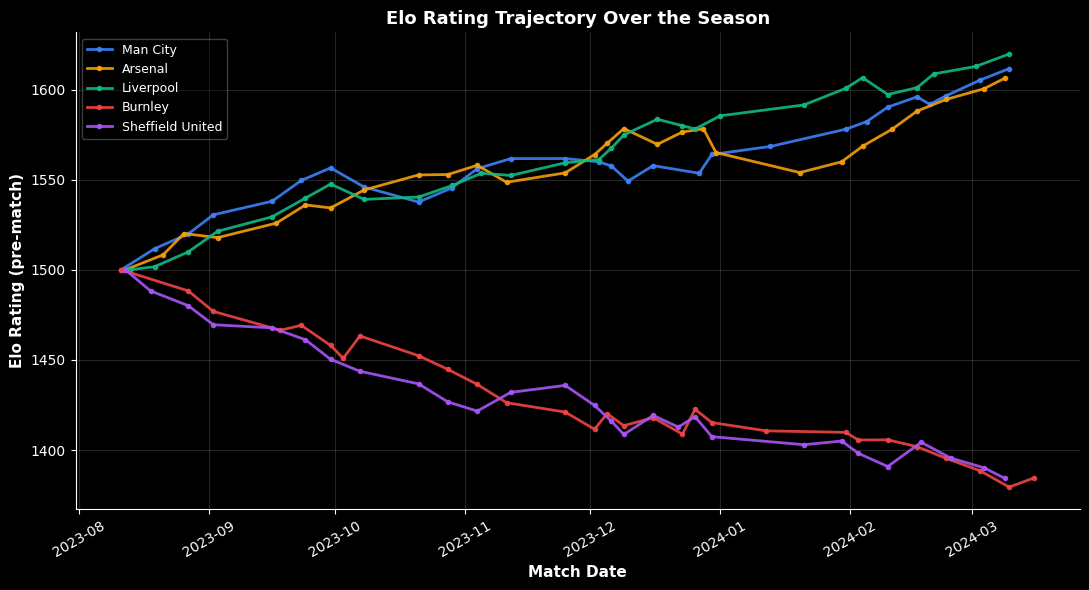

In [21]:
top_teams = ['Man City', 'Arsenal', 'Liverpool', 'Burnley', 'Sheffield United']
elo_history = data[data['team_playing'].isin(top_teams) & data['target'].notna()].copy()
elo_history = elo_history.sort_values('Date')

fig, ax = plt.subplots(figsize=(11, 6))
for team, color in zip(top_teams, PALETTE + ['#A855F7']):
    team_data = elo_history[elo_history['team_playing'] == team]
    ax.plot(team_data['Date'], team_data['tp_elo_pre'], marker='o', markersize=3,
            linewidth=2, label=team, color=color, alpha=0.9)
ax.set_xlabel('Match Date', fontsize=11, fontweight='bold')
ax.set_ylabel('Elo Rating (pre-match)', fontsize=11, fontweight='bold')
ax.set_title('Elo Rating Trajectory Over the Season', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=9, framealpha=0.3)
ax.spines[['top','right']].set_visible(False)
ax.grid(alpha=0.15)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('viz4_elo_trajectory.png', dpi=150, bbox_inches='tight', facecolor='#111111')
plt.show()

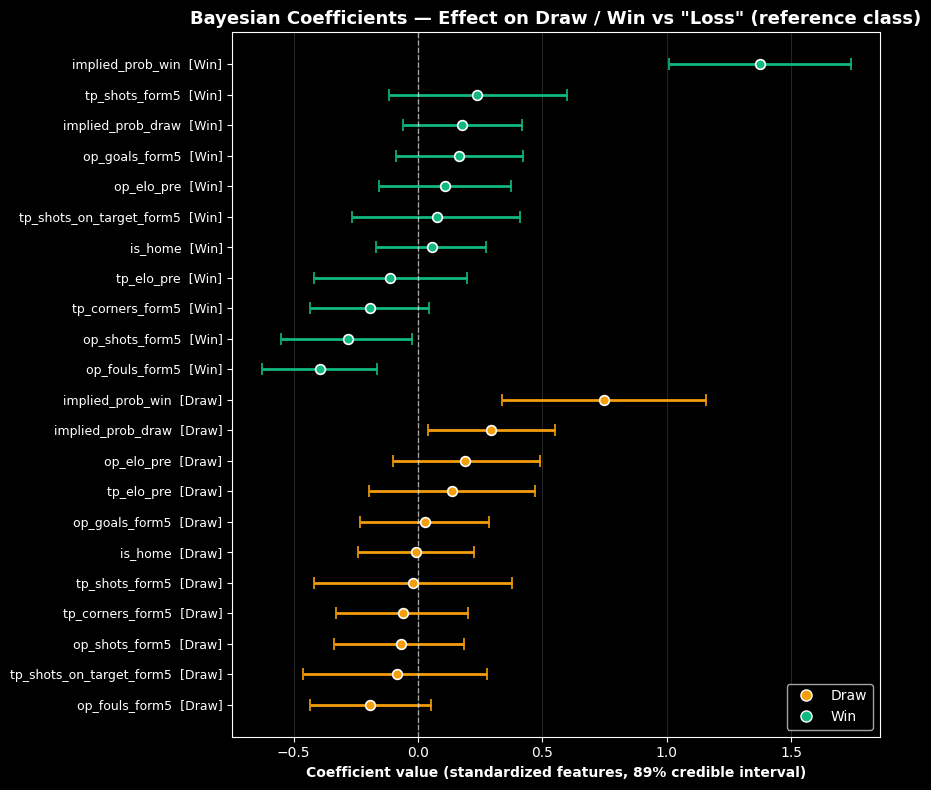

In [22]:
class_names = ['Draw', 'Win']  # relative to reference class "Loss"
beta_samples = trace.posterior['beta'].values
beta_samples = beta_samples.reshape(-1, beta_samples.shape[-2], beta_samples.shape[-1])

rows = []
for cls_idx, cls_name in enumerate(class_names):
    for feat_idx, feat_name in enumerate(selected_features):
        samples = beta_samples[:, cls_idx, feat_idx]
        rows.append({'label': f"{feat_name}  [{cls_name}]", 'class': cls_name,
                      'mean': samples.mean(), 'lo': np.percentile(samples, 5.5), 'hi': np.percentile(samples, 94.5)})
forest_df = pd.DataFrame(rows).sort_values(['class', 'mean']).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 8))
y_pos = np.arange(len(forest_df))
colors_map = {'Draw': PALETTE[1], 'Win': PALETTE[2]}
for cls_name, color in colors_map.items():
    mask = forest_df['class'] == cls_name
    sub = forest_df[mask]
    ax.errorbar(sub['mean'], y_pos[mask.values],
                xerr=[sub['mean'] - sub['lo'], sub['hi'] - sub['mean']],
                fmt='o', markersize=7, capsize=4, elinewidth=2, color=color, mec='white', mew=1.2, label=cls_name)
ax.axvline(0, color='white', linestyle='--', linewidth=1, alpha=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(forest_df['label'], fontsize=9)
ax.set_xlabel('Coefficient value (standardized features, 89% credible interval)', fontsize=10, fontweight='bold')
ax.set_title('Bayesian Coefficients — Effect on Draw / Win vs "Loss" (reference class)', fontsize=13, fontweight='bold')
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markeredgecolor='white', markersize=8, linestyle='')
           for c in colors_map.values()]
ax.legend(handles, colors_map.keys(), loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.15)
plt.tight_layout()
plt.savefig('viz5_coefficient_forest.png', dpi=150, bbox_inches='tight', facecolor='#111111')
plt.show()

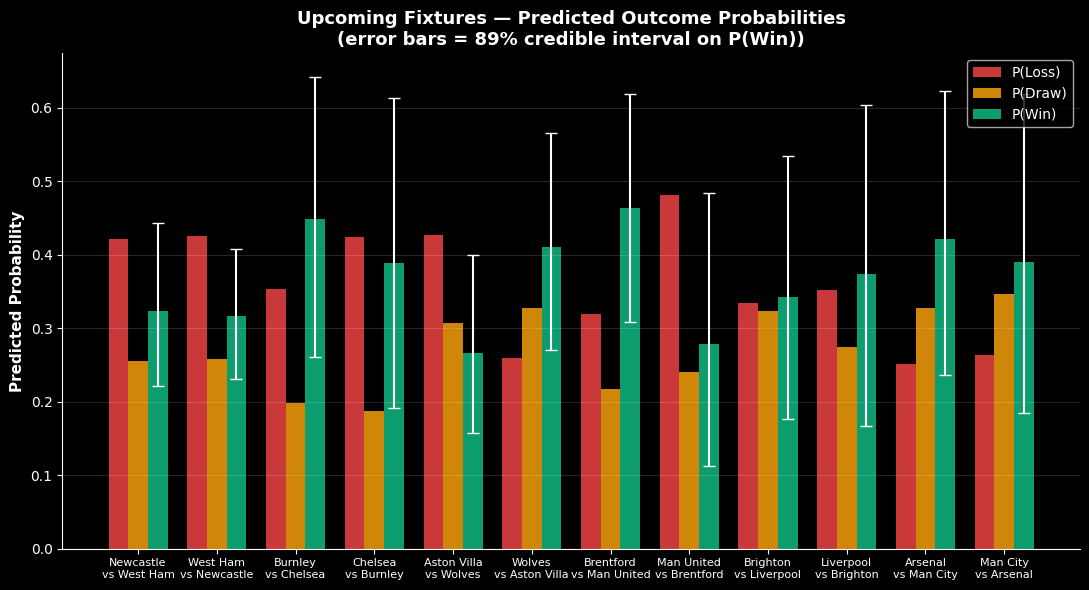

In [24]:
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(future_results))
width = 0.25

win_err = np.abs(np.vstack([
    future_results['P(Win)'].values - p_lo[:, 2],
    p_hi[:, 2] - future_results['P(Win)'].values
]))

ax.bar(x - width, future_results['P(Loss)'], width, label='P(Loss)', color=PALETTE[3], alpha=0.85)
ax.bar(x,         future_results['P(Draw)'], width, label='P(Draw)', color=PALETTE[1], alpha=0.85)
ax.bar(x + width, future_results['P(Win)'],  width, label='P(Win)',  color=PALETTE[2], alpha=0.85,
       yerr=win_err, capsize=4, error_kw={'ecolor': 'white', 'linewidth': 1.5})

fixture_labels = [f"{r.team_playing}\nvs {r.opponent}" for r in future_results.itertuples()]
ax.set_xticks(x)
ax.set_xticklabels(fixture_labels, fontsize=8)
ax.set_ylabel('Predicted Probability', fontsize=11, fontweight='bold')
ax.set_title('Upcoming Fixtures — Predicted Outcome Probabilities\n(error bars = 89% credible interval on P(Win))',
              fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.15)
plt.tight_layout()
plt.savefig('viz6_future_predictions.png', dpi=150, bbox_inches='tight', facecolor='#111111')
plt.show()